<a href="https://colab.research.google.com/github/mang-e/10/blob/main/%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%B6%84%EC%84%9D_2%EC%B0%A8%EC%8B%9C_%EC%BD%94%EB%93%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 데이터 편향이 AI에 미치는 영향

---

**실험 가설**
> *"동일한 AI 알고리즘이라도 학습 데이터가 달라지면 예측 결과가 달라진다."*

**실습 순서**

- Step 0 : 환경 준비
- Step 1 : 데이터 생성 및 시각화
- Step 2 : 편향 데이터 생성 및 비교
- Step 3 : AI 예측 비교 실험
- Step 4 : 수치로 편향 측정
- Step 5 : 직접 수정 체험

---
셀 왼쪽의 실행 버튼을 누르거나, 셀을 선택하고 `Shift + Enter`를 눌러 실행하세요.  
반드시 **Step 0부터 순서대로** 실행해야 합니다.

---
## Step 0. 환경 준비

한글 폰트 설치와 실습에 필요한 라이브러리를 불러옵니다.  
가장 먼저, 반드시 한 번 실행해주세요.

In [1]:
# 한글 폰트 설치 — 그래프에서 한글이 깨지지 않도록
!pip install koreanize-matplotlib -q

# pandas  : 데이터를 표 형태로 다루는 도구
# numpy   : 수학 계산을 빠르게 처리하는 도구
# matplotlib : 그래프를 그리는 도구
# sklearn : AI 모델을 만들고 평가하는 도구 모음 (사이킷런)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 난수 시드 고정 — 실행할 때마다 같은 결과가 나오도록
np.random.seed(2024)

print("환경 준비 완료. 다음 셀로 이동하세요.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 31.1 MB/s eta 0:00:00
환경 준비 완료. 다음 셀로 이동하세요.


---
## Step 1. 데이터 생성 및 시각화

가상의 고등학생 200명의 하루 공부시간과 모의고사 점수 데이터를 만듭니다.  
패턴을 명확하게 보여주기 위해 코드로 직접 생성한 데이터입니다.

In [2]:
# 공부시간 : 1~12시간 범위에서 200명 무작위 추출
# np.random.uniform(최솟값, 최댓값, 개수)
공부시간 = np.random.uniform(1, 12, 200)

# 점수 : 공부시간에 비례하되 개인차(노이즈)를 포함
# np.random.normal(평균, 표준편차, 개수) — 개인차를 표현하는 오차 생성
점수 = 공부시간 * 6.5 + np.random.normal(0, 9, 200) + 22

# np.clip : 값이 범위를 벗어나면 잘라냄 (10점 미만, 100점 초과 제거)
점수 = np.clip(점수, 10, 100).round(1)

# DataFrame : 열과 행으로 이루어진 표 형태로 정리
df_균형 = pd.DataFrame({
    '공부시간(h)': 공부시간.round(1),
    '모의고사점수': 점수
})

print("=" * 42)
print("  균형 데이터 기본 정보")
print("=" * 42)
print(f"  총 학생 수     : {len(df_균형)}명")
print(f"  공부시간 범위  : {df_균형['공부시간(h)'].min()}h ~ {df_균형['공부시간(h)'].max()}h")
print(f"  점수 평균      : {df_균형['모의고사점수'].mean():.1f}점")
print(f"  점수 표준편차  : {df_균형['모의고사점수'].std():.1f}점")
print()
print("  [ 상위 8행 미리보기 ]")
print(df_균형.head(8).to_string(index=False))

  균형 데이터 기본 정보
  총 학생 수     : 200명
  공부시간 범위  : 1.1h ~ 12.0h
  점수 평균      : 65.0점
  점수 표준편차  : 21.9점

  [ 상위 8행 미리보기 ]
 공부시간(h)  모의고사점수
     7.5    83.4
     8.7    75.2
     3.1    34.0
     1.5    33.3
     3.3    20.6
     2.2    60.4
     9.0    95.3
     8.5    76.5


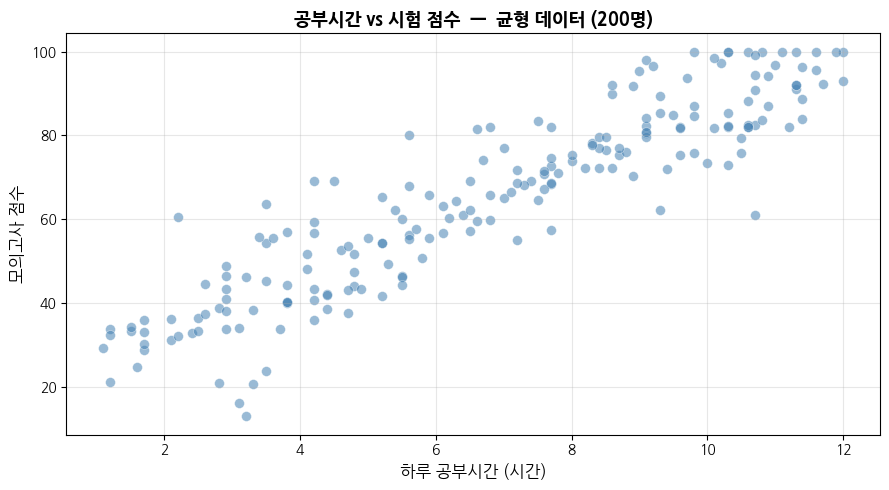

상관계수(r) = 0.913
  +1 에 가까울수록 강한 양의 상관관계
   0 에 가까울수록 관계 없음
  -1 에 가까울수록 강한 음의 상관관계


In [3]:
# 산점도 : x축과 y축에 각각 값을 배치하고 점을 찍어 관계를 시각화
# alpha  : 점의 투명도 (0 = 완전 투명, 1 = 불투명)
plt.figure(figsize=(9, 5))
plt.scatter(
    df_균형['공부시간(h)'],   # x축
    df_균형['모의고사점수'],  # y축
    alpha=0.55,
    color='steelblue',
    edgecolors='white',
    linewidth=0.4,
    s=50
)
plt.xlabel('하루 공부시간 (시간)', fontsize=12)
plt.ylabel('모의고사 점수', fontsize=12)
plt.title('공부시간 vs 시험 점수  —  균형 데이터 (200명)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 상관계수 : 두 변수가 얼마나 함께 움직이는지 -1 ~ +1 사이로 표현
# +1 에 가까울수록 강한 양의 관계, 0 이면 관계 없음, -1 에 가까울수록 반대 방향
corr = df_균형['공부시간(h)'].corr(df_균형['모의고사점수'])
print(f"상관계수(r) = {corr:.3f}")
print("  +1 에 가까울수록 강한 양의 상관관계")
print("   0 에 가까울수록 관계 없음")
print("  -1 에 가까울수록 강한 음의 상관관계")

**관찰 질문**
- 산점도에서 점들이 어떤 방향으로 분포되어 있나요?
- 공부시간이 같아도 점수가 다른 학생들이 있습니다. 그 이유는 무엇일까요?
- 상관계수 값이 의미하는 바를 자신의 말로 설명해보세요.

---
## Step 2. 편향 데이터 생성 및 비교

**시나리오** : 자사고·특목고처럼 공부를 많이 하는 학생 위주로만 데이터를 수집했다면?  
공부시간이 7시간 이상인 학생의 데이터만 있는 상황을 만들어 비교합니다.

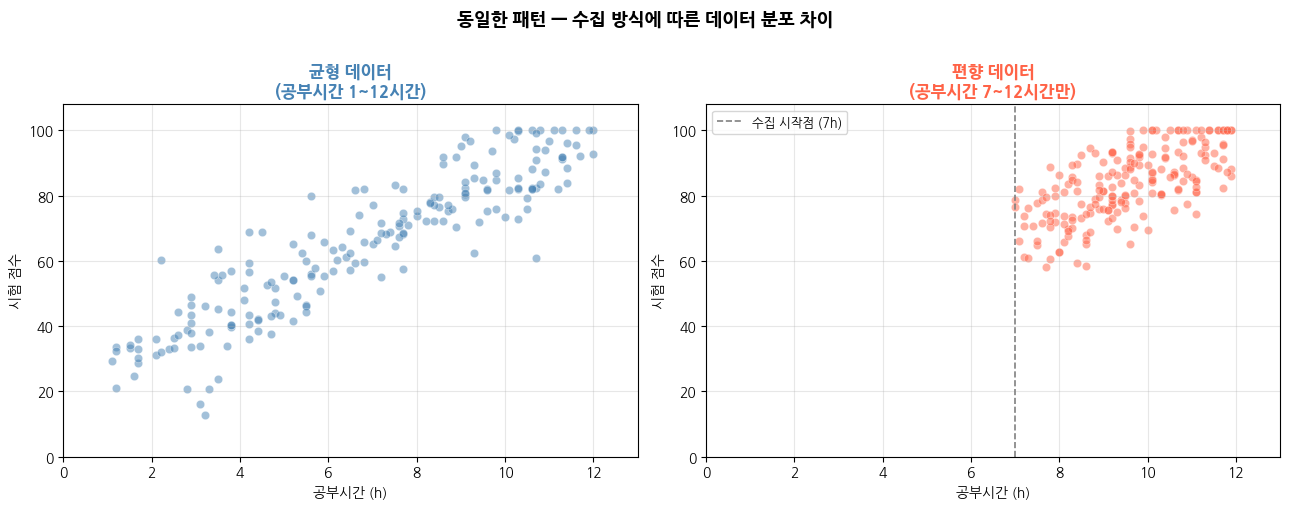

균형 데이터 상관계수  :  r = 0.913
편향 데이터 상관계수  :  r = 0.672

같은 패턴의 관계인데, 수집 범위에 따라 상관계수가 달라집니다.
데이터 수집 방식이 이미 분석의 결론 방향을 결정하고 있습니다.


In [4]:
# 편향 데이터 : 공부시간 7~12시간인 학생만 수집된 상황
# 1~6시간 구간 학생의 데이터는 처음부터 수집되지 않음
공부시간_편향 = np.random.uniform(7, 12, 200)
점수_편향 = 공부시간_편향 * 6.5 + np.random.normal(0, 9, 200) + 22
점수_편향 = np.clip(점수_편향, 10, 100).round(1)

df_편향 = pd.DataFrame({
    '공부시간(h)': 공부시간_편향.round(1),
    '모의고사점수': 점수_편향
})

# plt.subplots(1, 2) : 그래프 두 개를 1행 2열로 나란히 배치
# axes[0] = 왼쪽 그래프,  axes[1] = 오른쪽 그래프
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df_균형['공부시간(h)'], df_균형['모의고사점수'],
                alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.4)
axes[0].set_title('균형 데이터\n(공부시간 1~12시간)', fontsize=12, fontweight='bold', color='steelblue')
axes[0].set_xlabel('공부시간 (h)')
axes[0].set_ylabel('시험 점수')
axes[0].set_xlim(0, 13)
axes[0].set_ylim(0, 108)
axes[0].grid(True, alpha=0.3)

axes[1].scatter(df_편향['공부시간(h)'], df_편향['모의고사점수'],
                alpha=0.5, color='tomato', edgecolors='white', linewidth=0.4)
axes[1].set_title('편향 데이터\n(공부시간 7~12시간만)', fontsize=12, fontweight='bold', color='tomato')
axes[1].set_xlabel('공부시간 (h)')
axes[1].set_ylabel('시험 점수')
axes[1].set_xlim(0, 13)
axes[1].set_ylim(0, 108)
# axvline : 수직선 그리기 — 편향 데이터 수집 시작점(7시간)을 표시
axes[1].axvline(x=7, color='gray', linestyle='--', linewidth=1.2, label='수집 시작점 (7h)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('동일한 패턴 — 수집 방식에 따른 데이터 분포 차이', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

corr_편향 = df_편향['공부시간(h)'].corr(df_편향['모의고사점수'])
print(f"균형 데이터 상관계수  :  r = {corr:.3f}")
print(f"편향 데이터 상관계수  :  r = {corr_편향:.3f}")
print()
print("같은 패턴의 관계인데, 수집 범위에 따라 상관계수가 달라집니다.")
print("데이터 수집 방식이 이미 분석의 결론 방향을 결정하고 있습니다.")

**관찰 질문**
- 두 그래프에서 점들의 분포가 어떻게 다른가요?
- 편향 데이터에는 어떤 학생들의 정보가 빠져있나요?
- 현실에서 이런 편향은 어떻게 생겨날 수 있을까요? (채용 AI, 의료 AI 등)

---
## Step 3. AI 예측 비교 실험

두 데이터로 각각 AI 모델을 학습시키고, 동일한 질문에 어떻게 다른 답을 내놓는지 비교합니다.  
사용하는 알고리즘은 **선형 회귀(Linear Regression)** — 데이터의 패턴을 직선으로 표현하는 가장 기본적인 AI 모델입니다.

In [5]:
# LinearRegression() : 선형 회귀 모델 객체 생성
# .fit(X, y)         : AI에게 데이터를 주고 패턴을 학습하게 하는 명령
#                      X = 입력값(공부시간),  y = 정답(시험 점수)

모델_균형 = LinearRegression()
모델_균형.fit(df_균형[['공부시간(h)']], df_균형['모의고사점수'])

모델_편향 = LinearRegression()
모델_편향.fit(df_편향[['공부시간(h)']], df_편향['모의고사점수'])

print("두 AI 모델 학습 완료")
print()
print("[ AI가 찾아낸 규칙 비교 ]")
print(f"  균형 AI  :  공부 1시간 추가  ->  점수 {모델_균형.coef_[0]:.2f}점 상승")
print(f"  편향 AI  :  공부 1시간 추가  ->  점수 {모델_편향.coef_[0]:.2f}점 상승")
print()

# .predict([[값]]) : 학습된 패턴으로 새 값을 예측하는 명령
print("[ 공부시간별 예측 점수 비교 ]")
print(f"  {'공부시간':>5} | {'균형 AI':>10} | {'편향 AI':>10} | {'차이':>8}")
print("  " + "-" * 46)
for 시간 in [1, 2, 3, 5, 7, 9, 11]:
    p균 = 모델_균형.predict([[시간]])[0]
    p편 = 모델_편향.predict([[시간]])[0]
    diff = p균 - p편
    print(f"  {시간:3d}시간  | {p균:>8.1f}점 | {p편:>8.1f}점 | {diff:>+7.1f}점")

두 AI 모델 학습 완료

[ AI가 찾아낸 규칙 비교 ]
  균형 AI  :  공부 1시간 추가  ->  점수 6.52점 상승
  편향 AI  :  공부 1시간 추가  ->  점수 5.43점 상승

[ 공부시간별 예측 점수 비교 ]
   공부시간 |      균형 AI |      편향 AI |       차이
  ----------------------------------------------
    1시간  |     27.1점 |     37.1점 |   -10.1점
    2시간  |     33.6점 |     42.6점 |    -9.0점
    3시간  |     40.1점 |     48.0점 |    -7.9점
    5시간  |     53.1점 |     58.9점 |    -5.7점
    7시간  |     66.2점 |     69.7점 |    -3.5점
    9시간  |     79.2점 |     80.6점 |    -1.4점
   11시간  |     92.3점 |     91.5점 |    +0.8점


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


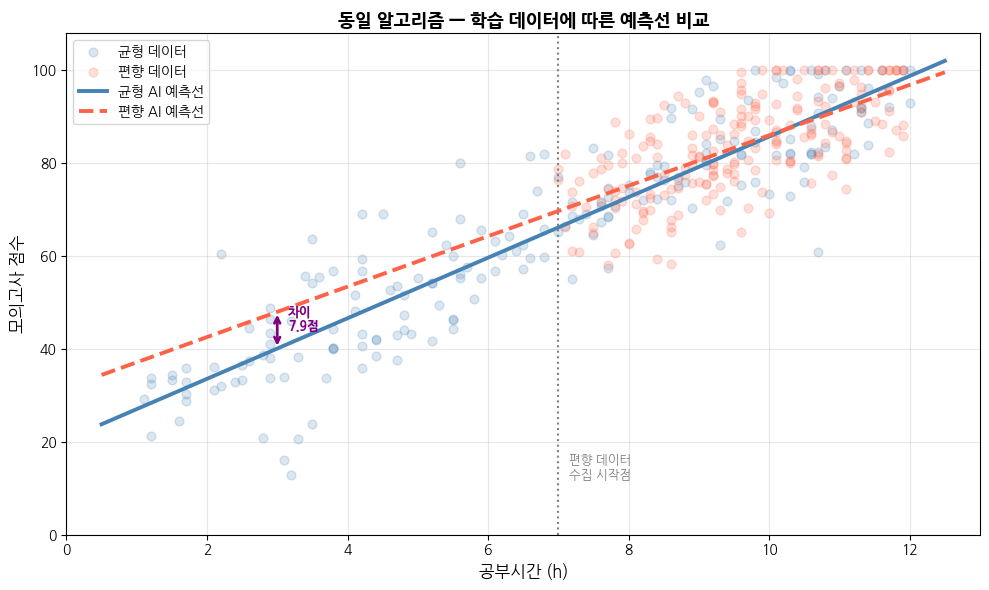

두 예측선은 7시간 이상 구간에서 비슷하게 움직입니다.
7시간 미만 구간에서는 크게 갈라집니다.
편향 AI는 그 구간의 학생 데이터를 학습한 적이 없기 때문입니다.


In [6]:
# np.linspace(시작, 끝, 개수) : 일정 간격으로 숫자를 생성
# .reshape(-1, 1)             : 1열짜리 2차원 배열로 변환 (predict 입력 형식)
x_plot = np.linspace(0.5, 12.5, 300).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(10, 6))

# 데이터 점 (투명하게)
ax.scatter(df_균형['공부시간(h)'], df_균형['모의고사점수'],
           alpha=0.2, color='steelblue', s=40, label='균형 데이터')
ax.scatter(df_편향['공부시간(h)'], df_편향['모의고사점수'],
           alpha=0.2, color='tomato', s=40, label='편향 데이터')

# 예측선 : x 값들을 넣어 예측한 y값들을 선으로 이음
ax.plot(x_plot, 모델_균형.predict(x_plot),
        color='steelblue', linewidth=2.8, label='균형 AI 예측선')
ax.plot(x_plot, 모델_편향.predict(x_plot),
        color='tomato', linewidth=2.8, linestyle='--', label='편향 AI 예측선')

# 편향 데이터 수집 시작점 표시
ax.axvline(x=7, color='gray', linestyle=':', linewidth=1.5)
ax.text(7.15, 12, '편향 데이터\n수집 시작점', fontsize=9, color='gray')

# annotate : 그래프 위에 화살표와 텍스트를 함께 표시
# arrowstyle='<->' : 양방향 화살표
p균_3 = 모델_균형.predict([[3]])[0]
p편_3 = 모델_편향.predict([[3]])[0]
ax.annotate('', xy=(3, p편_3), xytext=(3, p균_3),
            arrowprops=dict(arrowstyle='<->', color='purple', lw=2))
ax.text(3.15, (p균_3 + p편_3) / 2,
        f"차이\n{abs(p균_3 - p편_3):.1f}점",
        color='purple', fontsize=9, fontweight='bold')

ax.set_xlabel('공부시간 (h)', fontsize=12)
ax.set_ylabel('모의고사 점수', fontsize=12)
ax.set_title('동일 알고리즘 — 학습 데이터에 따른 예측선 비교', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 13)
ax.set_ylim(0, 108)
plt.tight_layout()
plt.show()

print("두 예측선은 7시간 이상 구간에서 비슷하게 움직입니다.")
print("7시간 미만 구간에서는 크게 갈라집니다.")
print("편향 AI는 그 구간의 학생 데이터를 학습한 적이 없기 때문입니다.")

---
## Step 4. 수치로 편향 측정

두 모델의 성능을 R²와 RMSE로 비교합니다.  
비교 구간은 편향 AI의 맹점인 **공부시간 1~6시간 구간**입니다.

In [7]:
# 균형 데이터에서 공부시간 6시간 이하인 행만 추출
# .copy() : 원본 데이터를 건드리지 않도록 복사본 생성
df_저공부 = df_균형[df_균형['공부시간(h)'] <= 6].copy()

# 두 AI가 이 구간 학생들의 점수를 각각 예측
p_균형_저 = 모델_균형.predict(df_저공부[['공부시간(h)']])
p_편향_저 = 모델_편향.predict(df_저공부[['공부시간(h)']])

# R²  (결정계수) : 모델이 데이터 변동을 얼마나 설명하는지
#                  1 = 완벽한 예측 / 0 = 예측력 없음 / 음수 = 평균보다 못함
r2_균 = r2_score(df_저공부['모의고사점수'], p_균형_저)
r2_편 = r2_score(df_저공부['모의고사점수'], p_편향_저)

# RMSE (평균제곱근오차) : 예측값과 실제값의 평균 차이 (단위: 점)
#                         낮을수록 오차가 작음
rmse_균 = np.sqrt(mean_squared_error(df_저공부['모의고사점수'], p_균형_저))
rmse_편 = np.sqrt(mean_squared_error(df_저공부['모의고사점수'], p_편향_저))

print("=" * 50)
print("  공부시간 1~6시간 구간  —  두 AI 성능 비교")
print("=" * 50)
print(f"  {'지표':<16} {'균형 AI':>10} {'편향 AI':>10}")
print("  " + "-" * 38)
print(f"  {'R²  (결정계수)':<16} {r2_균:>10.3f} {r2_편:>10.3f}")
print(f"  {'RMSE (평균제곱근오차)':<16} {rmse_균:>8.2f}점 {rmse_편:>8.2f}점")
print()
print("  R²  : 1에 가까울수록 예측 정확 / 0이면 예측력 없음")
print("  RMSE: 낮을수록 오차 작음 (단위: 점수)")
print()
print(f"  -> 이 구간에서 편향 AI의 평균 오차가 {rmse_편 - rmse_균:.1f}점 더 큽니다.")

  공부시간 1~6시간 구간  —  두 AI 성능 비교
  지표                    균형 AI      편향 AI
  --------------------------------------
  R²  (결정계수)            0.417      0.053
  RMSE (평균제곱근오차)       9.91점    12.63점

  R²  : 1에 가까울수록 예측 정확 / 0이면 예측력 없음
  RMSE: 낮을수록 오차 작음 (단위: 점수)

  -> 이 구간에서 편향 AI의 평균 오차가 2.7점 더 큽니다.


---
## Step 5. 직접 수정 체험

아래 코드에서 `# 수정 가능` 표시가 있는 두 줄의 숫자를 바꾸고 실행해보세요.  
나머지 코드는 건드리지 않아도 됩니다.

In [8]:
# --------------------------------------------------
# 수정 가능 : 예측할 공부시간 목록 (1~12 사이 숫자)
예측할_공부시간 = [2, 4, 6, 8, 10]

# 수정 가능 : 편향 데이터 수집 시작 시간 (기본값 7, 범위 4~10)
#             낮출수록 편향이 줄고, 높일수록 편향이 커집니다
편향_시작_시간 = 7
# --------------------------------------------------

# 수정한 시작 시간으로 새 편향 데이터 생성
시간_새편향 = np.random.uniform(편향_시작_시간, 12, 200)
점수_새편향 = 시간_새편향 * 6.5 + np.random.normal(0, 9, 200) + 22
점수_새편향 = np.clip(점수_새편향, 10, 100).round(1)
df_새편향 = pd.DataFrame({
    '공부시간(h)': 시간_새편향.round(1),
    '모의고사점수': 점수_새편향
})

# 새 편향 데이터로 모델 학습
모델_새편향 = LinearRegression()
모델_새편향.fit(df_새편향[['공부시간(h)']], df_새편향['모의고사점수'])

# 결과 출력
print(f"[ 편향 데이터 수집 범위 : {편향_시작_시간}시간 ~ 12시간 ]")
print()
print(f"  {'공부시간':>5} | {'균형 AI':>10} | {'수정 편향 AI':>12} | {'차이':>8} |")
print("  " + "-" * 52)
for 시간 in 예측할_공부시간:
    p균 = 모델_균형.predict([[시간]])[0]
    p새 = 모델_새편향.predict([[시간]])[0]
    diff = p균 - p새
    범위 = "편향 구간 내" if 시간 >= 편향_시작_시간 else "편향 구간 밖"
    print(f"  {시간:3d}시간  | {p균:>8.1f}점 | {p새:>10.1f}점 | {diff:>+7.1f}점 | {범위}")

print()
print("편향_시작_시간을 낮추면 두 AI의 차이가 어떻게 달라지나요?")
print("높이면 어떻게 달라지나요? 결과를 기록해보세요.")

[ 편향 데이터 수집 범위 : 7시간 ~ 12시간 ]

   공부시간 |      균형 AI |     수정 편향 AI |       차이 |
  ----------------------------------------------------
    2시간  |     33.6점 |       35.5점 |    -1.9점 | 편향 구간 밖
    4시간  |     46.6점 |       48.2점 |    -1.5점 | 편향 구간 밖
    6시간  |     59.7점 |       60.9점 |    -1.2점 | 편향 구간 밖
    8시간  |     72.7점 |       73.5점 |    -0.8점 | 편향 구간 내
   10시간  |     85.8점 |       86.2점 |    -0.5점 | 편향 구간 내

편향_시작_시간을 낮추면 두 AI의 차이가 어떻게 달라지나요?
높이면 어떻게 달라지나요? 결과를 기록해보세요.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/

---
## 정리

**오늘 실험에서 확인한 것**

- 동일한 알고리즘(선형 회귀)도 학습 데이터가 달라지면 완전히 다른 예측을 내놓습니다.
- 편향 AI는 학습하지 못한 구간에서 체계적으로 오류를 만들어냅니다.
- 이 오류는 의도하지 않아도 데이터 수집 방식만으로 발생합니다.

**생각해볼 질문**

1. 현실의 AI 시스템(추천 알고리즘, 채용 AI, 의료 AI)에서 이런 편향이 생기면 누가 가장 피해를 받을까요?
2. 편향을 줄이려면 데이터 수집 단계에서 어떤 점을 고려해야 할까요?
3. AI의 결과를 신뢰하기 전에 어떤 질문을 먼저 해야 할까요?

---

> **"이 AI는 누구의 데이터로 학습했는가?  그리고 누구의 데이터가 빠져 있는가?"**